# ADS-502 – Health / Medical Feature Group EDA  
**Notebook:** `bereket_initial_EDA.ipynb`  

This notebook is self-contained for **Week 1 + Week 2** Python work on the
CDC BRFSS/LLCP 2014 dataset (LLCP2014.XPT) focusing on the **health/medical**
feature group.

It:

1. Loads the SAS XPORT file into a pandas DataFrame (`df`)
2. Cleans column names (lowercase, underscores)
3. Dynamically detects the correct column names for the health/medical features
4. Performs Week 2 EDA, recoding, and data quality reporting.


## 0. Load data and clean column names

> If you already loaded `df` earlier in a separate Week 1 notebook,
> you can skip this cell.  
> But running this here makes the notebook self-contained.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\bezaa\OneDrive\Desktop\python learning\datamining\Project\LLCP2014XPT\LLCP2014.XPT"

df = pd.read_sas(file_path, format="xport", encoding="latin-1")

# Clean column names
df.columns = (
    df.columns
      .str.lower()
      .str.replace('-', '_')
      .str.replace(' ', '_')
)

print("Shape:", df.shape)
df.head()



Shape: (464664, 279)


,_state,fmonth,idate,imonth,iday,iyear,dispcode,seqno,_psu,ctelenum,...,_fobtfs,_crcrec,_aidtst3,_impeduc,_impmrtl,_imphome,rcsbrac1,rcsrace1,rchisla1,rcsbirth
0,1.0,1.0,01172014,01,17,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,5.0,1.0,1.0,NaN,,,
1,1.0,1.0,01072014,01,07,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,2.0,2.0,4.0,1.0,1.0,NaN,,,
2,1.0,1.0,01092014,01,09,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,2.0,2.0,6.0,1.0,1.0,NaN,,,
3,1.0,1.0,01072014,01,07,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,6.0,3.0,1.0,NaN,,,
4,1.0,1.0,01162014,01,16,2014,1100.0,2.014000e+09,2.014000e+09,1.0,...,2.0,1.0,2.0,5.0,1.0,1.0,NaN,,,


## 1. Detect health / medical feature columns dynamically

Different BRFSS years sometimes use slightly different variable names
(for example, with or without a leading underscore).  
To avoid `KeyError: not in index`, we detect the **actual** column names
present in `df` for each health concept.


In [5]:
all_cols = set(df.columns.tolist())

# Candidate names for each concept
candidate_map = {
    'diabetes':   ['diabete3', '_diabete3'],
    'highbp':     ['highbp', '_highbp'],
    'highchol':   ['highchol', '_highchol'],
    'bmi5':       ['bmi5', '_bmi5'],
    'physhlth':   ['physhlth', '_physhlth'],
    'menthlth':   ['menthlth', '_menthlth'],
    'smoker3':    ['smoker3', '_smoker3'],
    'alcday5':    ['alcday5', '_alcday5'],
    'exerany2':   ['exerany2', '_exerany2'],
    'genhlth':    ['genhlth', '_genhlth'],
}

selected_cols = {}

for concept, candidates in candidate_map.items():
    for c in candidates:
        if c.lower() in all_cols:
            selected_cols[concept] = c.lower()
            break

print("Selected columns for health feature group:")
for k, v in selected_cols.items():
    print(f"  {k:10s} -> {v}")

health_feature_cols = list(selected_cols.values())

print("\nFinal health feature columns used:")
print(health_feature_cols)

df_health = df[health_feature_cols].copy()
df_health.head()

Selected columns for health feature group:
  diabetes   -> diabete3
  bmi5       -> _bmi5
  physhlth   -> physhlth
  menthlth   -> menthlth
  smoker3    -> _smoker3
  alcday5    -> alcday5
  exerany2   -> exerany2
  genhlth    -> genhlth

Final health feature columns used:
['diabete3', '_bmi5', 'physhlth', 'menthlth', '_smoker3', 'alcday5', 'exerany2', 'genhlth']


,diabete3,_bmi5,physhlth,menthlth,_smoker3,alcday5,exerany2,genhlth
0,1.0,2551.0,25.0,5.0,3.0,888.0,2.0,5.0
1,3.0,2495.0,7.0,14.0,4.0,888.0,1.0,3.0
2,3.0,3730.0,88.0,88.0,3.0,888.0,1.0,1.0
3,1.0,5442.0,77.0,77.0,4.0,888.0,2.0,3.0
4,3.0,3712.0,2.0,88.0,4.0,888.0,2.0,3.0


## 2. Missing value analysis

We compute count and percent missing for each selected health/medical variable,
then visualize missingness with a bar chart.


In [7]:
def missing_summary(df_in):
    """Return table with missing count and percent for each column."""
    n = len(df_in)
    missing_count = df_in.isna().sum()
    missing_pct = missing_count / n * 100
    out = (
        pd.DataFrame({
            'missing_count': missing_count,
            'missing_pct': missing_pct.round(2)
        })
        .sort_values('missing_pct', ascending=False)
    )
    return out

missing_table = missing_summary(df_health)
missing_table

,missing_count,missing_pct
_bmi5,30694,6.61
alcday5,19299,4.15
physhlth,4,0.00
diabete3,2,0.00
menthlth,1,0.00
_smoker3,0,0.00
exerany2,4,0.00
genhlth,4,0.00


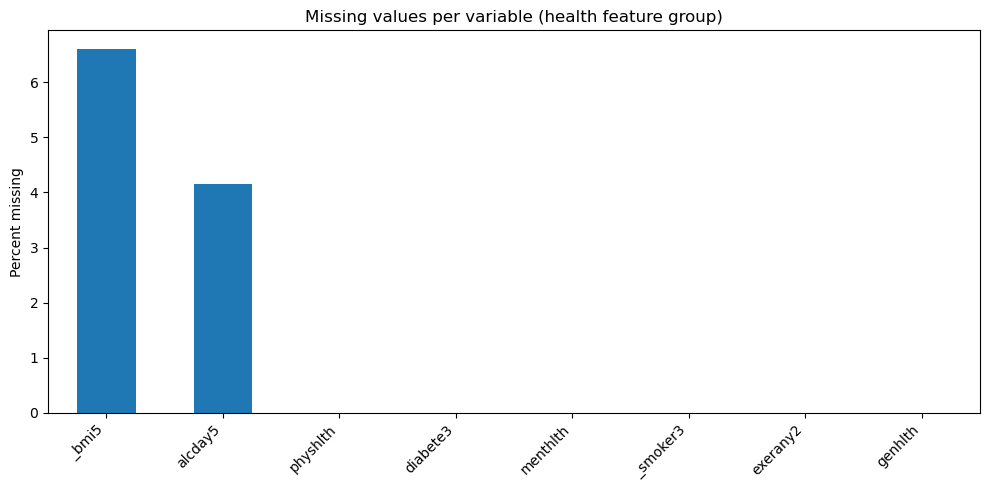

In [8]:
plt.figure(figsize=(10, 5))
missing_table['missing_pct'].plot(kind='bar')
plt.ylabel('Percent missing')
plt.title('Missing values per variable (health feature group)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Basic distributions and outlier checks

We separate numeric and non-numeric variables, then create:

- Histograms for numeric variables
- Boxplots for numeric variables
- Value counts (top 10) for categorical variables


In [10]:
numeric_cols = df_health.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df_health.columns if c not in numeric_cols]

numeric_cols, categorical_cols

(['diabete3',
  '_bmi5',
  'physhlth',
  'menthlth',
  '_smoker3',
  'alcday5',
  'exerany2',
  'genhlth'],
 [])

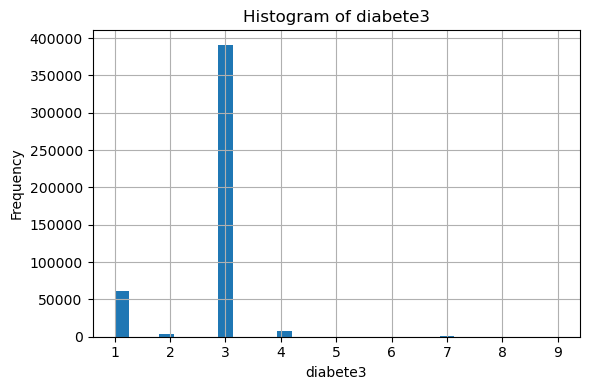

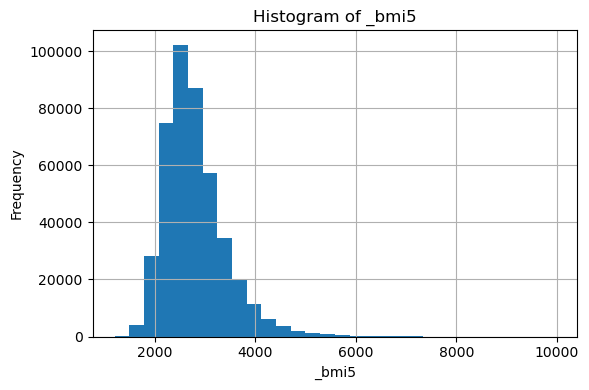

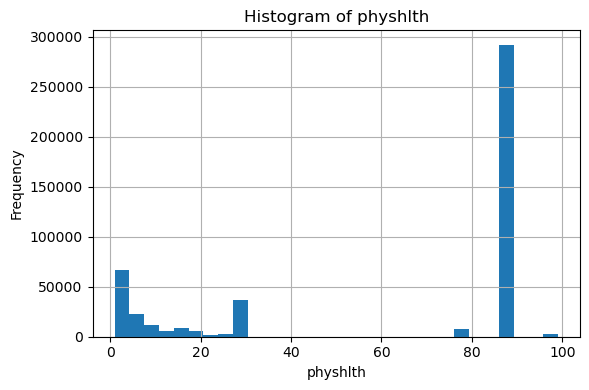

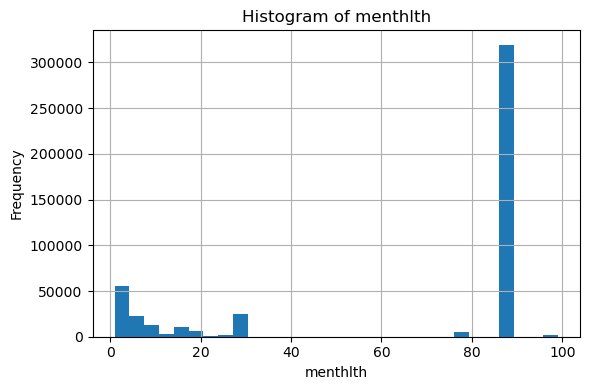

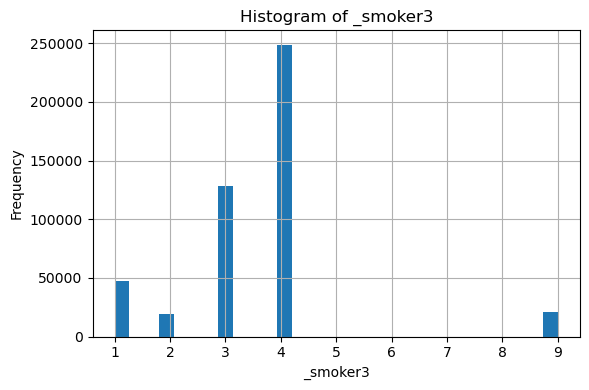

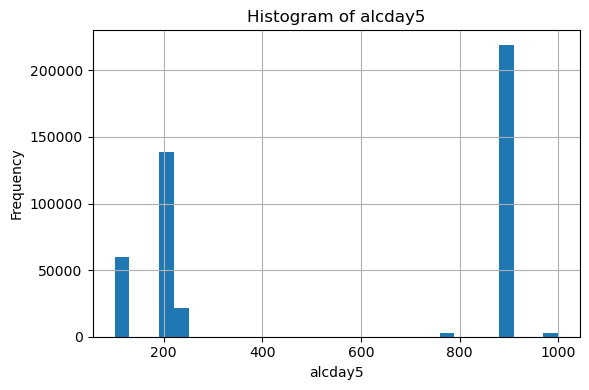

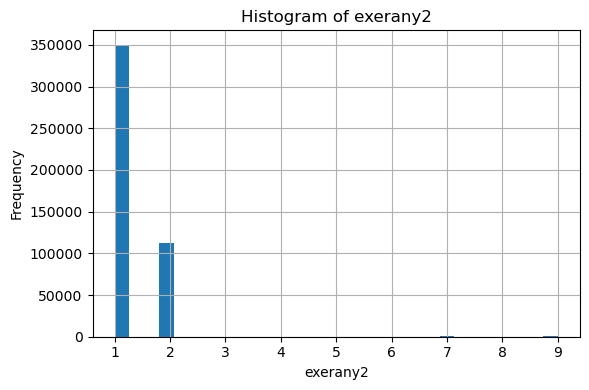

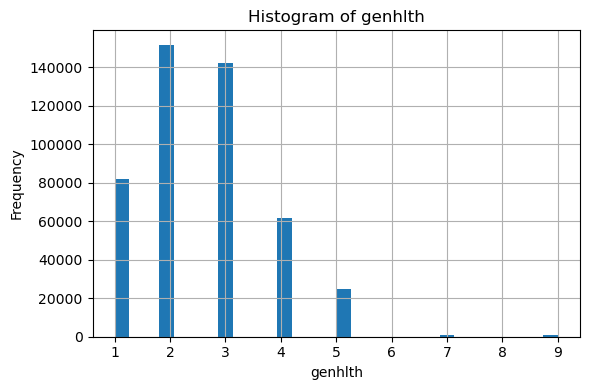

In [11]:
# Histograms for numeric variables
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df_health[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

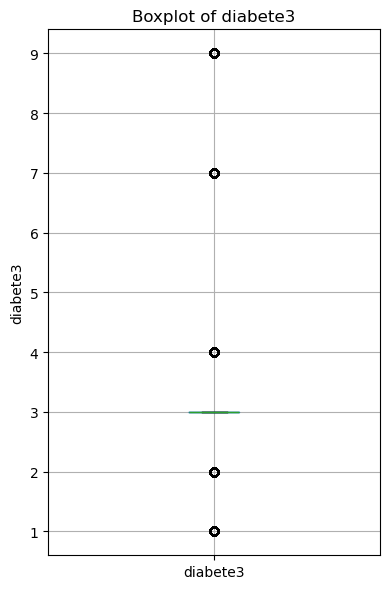

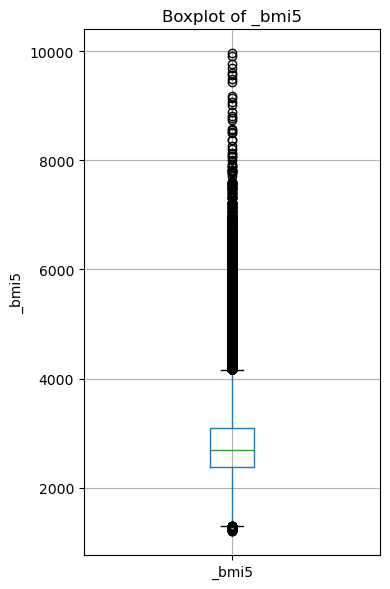

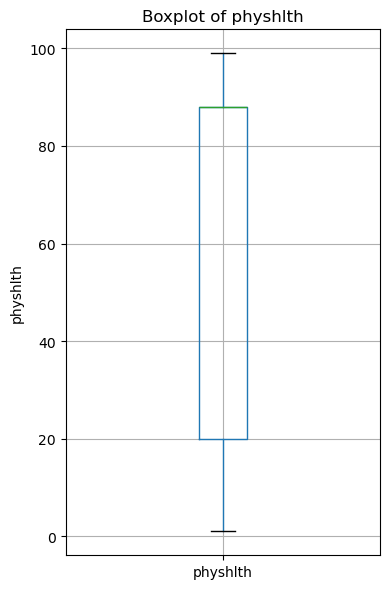

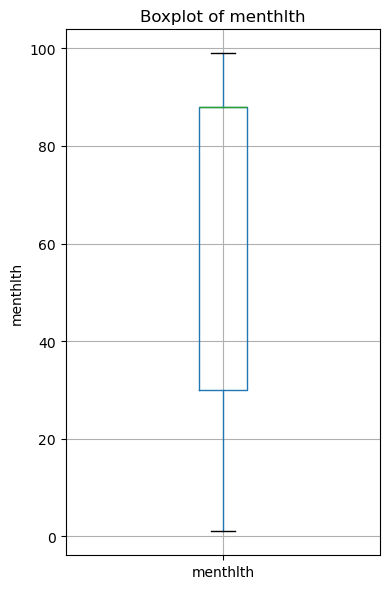

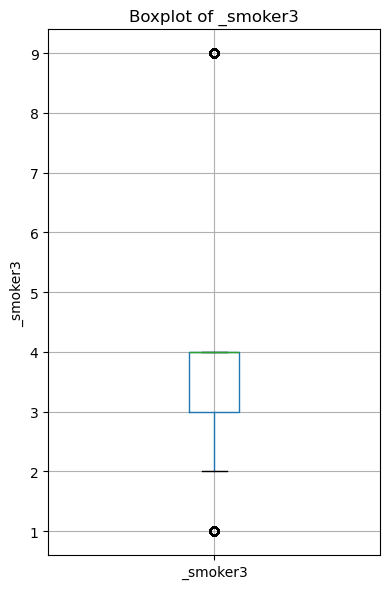

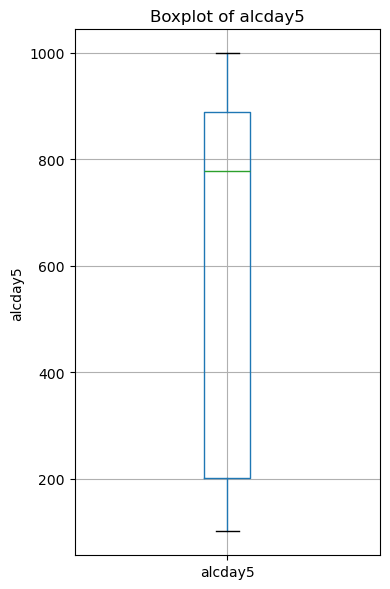

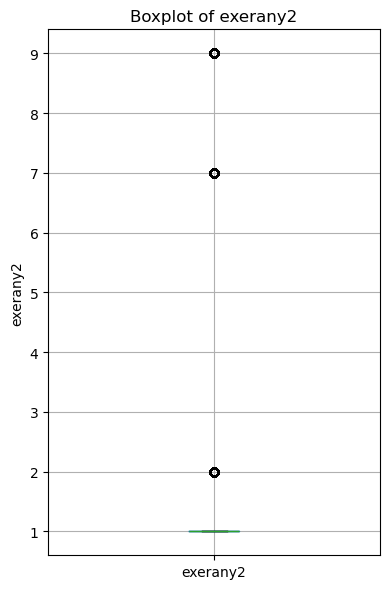

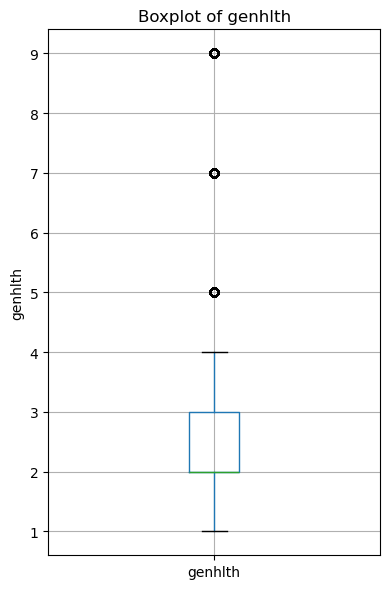

In [12]:
# Boxplots for numeric variables
for col in numeric_cols:
    plt.figure(figsize=(4, 6))
    df_health.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [13]:
# Value counts for categorical variables
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df_health[col].value_counts(dropna=False).head(10))

## 4. Recoding invalid / special codes and creating a cleaned dataset

We now apply typical BRFSS-style recoding rules.  
Because column names may differ (underscore vs no underscore),
we always refer to the **selected column names** in `selected_cols`.


In [15]:
df_health_clean = df_health.copy()

def replace_with_nan(series, codes):
    return series.replace(codes, np.nan)

# Diabetes
col_diab = selected_cols.get('diabetes')
if col_diab is not None:
    df_health_clean[col_diab] = replace_with_nan(df_health_clean[col_diab], [7, 9])

# High BP
col_hbp = selected_cols.get('highbp')
if col_hbp is not None:
    df_health_clean[col_hbp] = replace_with_nan(df_health_clean[col_hbp], [7, 9])

# High cholesterol
col_hchol = selected_cols.get('highchol')
if col_hchol is not None:
    df_health_clean[col_hchol] = replace_with_nan(df_health_clean[col_hchol], [7, 9])

# BMI (bmi5-style, scaled by 100)
col_bmi5 = selected_cols.get('bmi5')
if col_bmi5 is not None:
    df_health_clean[col_bmi5] = replace_with_nan(df_health_clean[col_bmi5], [9999])
    df_health_clean['bmi'] = df_health_clean[col_bmi5] / 100.0

# Physical and mental health days
for concept in ['physhlth', 'menthlth']:
    col = selected_cols.get(concept)
    if col is not None:
        df_health_clean[col] = df_health_clean[col].replace(88, 0)
        df_health_clean[col] = replace_with_nan(df_health_clean[col], [77, 99])

# Smoking, alcohol, exercise, general health
col_smoker = selected_cols.get('smoker3')
if col_smoker is not None:
    df_health_clean[col_smoker] = replace_with_nan(df_health_clean[col_smoker], [7, 9])

col_alc = selected_cols.get('alcday5')
if col_alc is not None:
    df_health_clean[col_alc] = replace_with_nan(df_health_clean[col_alc], [777, 999])

col_exer = selected_cols.get('exerany2')
if col_exer is not None:
    df_health_clean[col_exer] = replace_with_nan(df_health_clean[col_exer], [7, 9])

col_gen = selected_cols.get('genhlth')
if col_gen is not None:
    df_health_clean[col_gen] = replace_with_nan(df_health_clean[col_gen], [7, 9])

# Missing summary after recoding
missing_summary(df_health_clean)

,missing_count,missing_pct
_bmi5,30694,6.61
bmi,30694,6.61
alcday5,25447,5.48
_smoker3,21171,4.56
physhlth,10303,2.22
menthlth,7962,1.71
exerany2,1727,0.37
genhlth,1692,0.36
diabete3,844,0.18


## 5. Create binary diabetes target variable

We define a binary target for modeling where:

- `1` → diabetes **yes**
- `0` → diabetes **no**
- Other codes (pre-/gestational, missing, etc.) → `NaN`


In [17]:
col_diab = selected_cols.get('diabetes')

def diabetes_binary(v):
    if v == 1:
        return 1
    elif v == 2:
        return 0
    else:
        return np.nan

if col_diab is not None:
    df_health_clean['diabetes_binary'] = df_health_clean[col_diab].apply(diabetes_binary)
    print(df_health_clean['diabetes_binary'].value_counts(dropna=False))
else:
    print("No diabetes column found in selected_cols; cannot create diabetes_binary.")

diabetes_binary
NaN    399339
1.0     61118
0.0      4207
Name: count, dtype: int64


## 6. Data quality summary table

This table can be used directly in your **Data Quality Report** section.


In [19]:
def data_quality_report(df_in):
    rows = []
    n = len(df_in)
    for col in df_in.columns:
        series = df_in[col]
        missing_count = series.isna().sum()
        missing_pct = missing_count / n * 100
        n_unique = series.nunique(dropna=True)
        dtype = series.dtype

        min_val = series.min() if np.issubdtype(dtype, np.number) else None
        max_val = series.max() if np.issubdtype(dtype, np.number) else None

        rows.append({
            'variable': col,
            'dtype': str(dtype),
            'n_unique': n_unique,
            'missing_count': missing_count,
            'missing_pct': round(missing_pct, 2),
            'min': min_val,
            'max': max_val
        })

    return pd.DataFrame(rows).sort_values('missing_pct', ascending=False)

dq_table = data_quality_report(df_health_clean)
dq_table

,variable,dtype,n_unique,missing_count,missing_pct,min,max
9,diabetes_binary,float64,2,399339,85.94,0.00,1.00
1,_bmi5,float64,3750,30694,6.61,1201.00,9963.00
8,bmi,float64,3750,30694,6.61,12.01,99.63
5,alcday5,float64,38,25447,5.48,101.00,888.00
4,_smoker3,float64,4,21171,4.56,1.00,4.00
2,physhlth,float64,31,10303,2.22,0.00,30.00
3,menthlth,float64,31,7962,1.71,0.00,30.00
6,exerany2,float64,2,1727,0.37,1.00,2.00
7,genhlth,float64,5,1692,0.36,1.00,5.00
0,diabete3,float64,4,844,0.18,1.00,4.00


In [20]:
# Optional: export to CSV for reporting
dq_table.to_csv('health_feature_data_quality_week2.csv', index=False)

## 7. Updated visualizations after cleaning

These plots are based on the cleaned health/medical variables and
are suitable for inclusion in your project report.


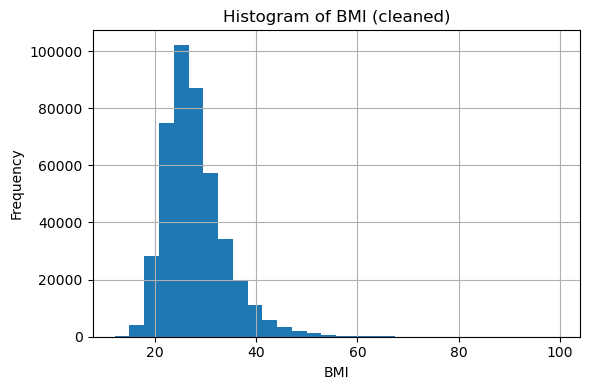

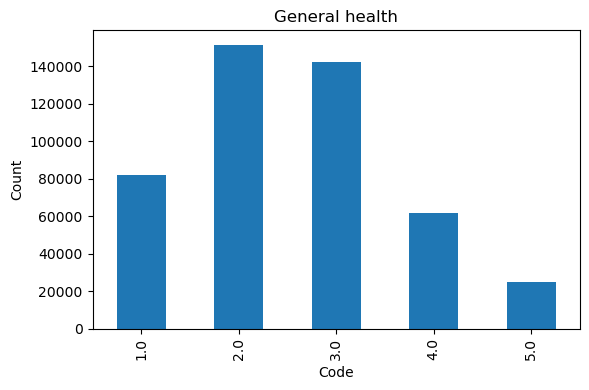

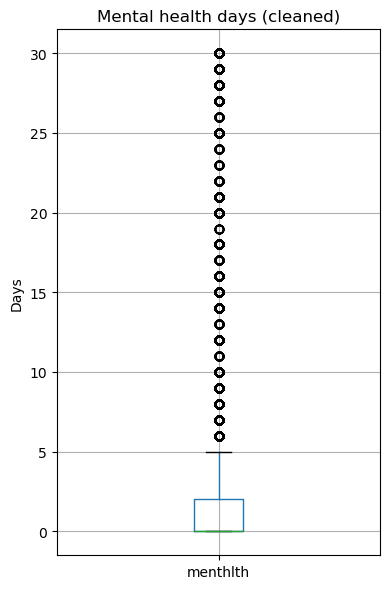

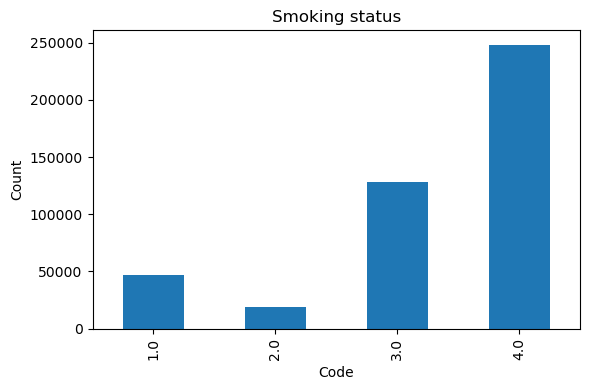

In [22]:
# Histogram of cleaned BMI (only if BMI exists)
if 'bmi' in df_health_clean.columns:
    plt.figure(figsize=(6, 4))
    df_health_clean['bmi'].hist(bins=30)
    plt.title('Histogram of BMI (cleaned)')
    plt.xlabel('BMI')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Bar plot of general health
col_gen = selected_cols.get('genhlth')
if col_gen is not None:
    plt.figure(figsize=(6, 4))
    df_health_clean[col_gen].value_counts().sort_index().plot(kind='bar')
    plt.title('General health')
    plt.xlabel('Code')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Boxplot of mental health days
col_ment = selected_cols.get('menthlth')
if col_ment is not None:
    plt.figure(figsize=(4, 6))
    df_health_clean.boxplot(column=col_ment)
    plt.title('Mental health days (cleaned)')
    plt.ylabel('Days')
    plt.tight_layout()
    plt.show()

# Smoking status distribution
col_smoker = selected_cols.get('smoker3')
if col_smoker is not None:
    plt.figure(figsize=(6, 4))
    df_health_clean[col_smoker].value_counts().sort_index().plot(kind='bar')
    plt.title('Smoking status')
    plt.xlabel('Code')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()